# Task A — Airbnb NYC 2019 (Regression)

**Student name:** Brenda Esteves 
**Course:** BANA 620 — Predictive Analytics & Data Mining  

**Business scenario:** You are helping Airbnb build a suggested-nightly-price tool for new NYC hosts. Predict price from neighborhood, room type, and listing activity.

Read the project instructions PDF before starting. Use Claude Code to help you fill in each section. Answer the conceptual questions in the **Canvas quiz**, not in this notebook.

**Important:** Use `random_state=42` everywhere. You must be able to explain every line of code you run.

## Imports

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

RANDOM_STATE = 42
pd.set_option('display.max_columns', 50)

In [72]:
airbnb = pd.read_csv('data/airbnb_nyc_2019.csv')
print(airbnb.shape)
airbnb.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## A.1 — Descriptive Analysis

Report shape, dtypes, missing-value summary, price distribution plot, medians by `neighbourhood_group` and `room_type`, top 5 neighbourhoods by listing count.

Shape: (48895, 16)

Data Types:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Missing Values:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                 

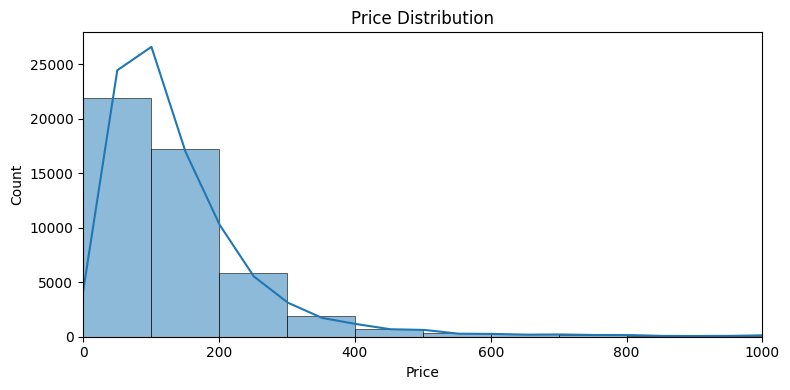


Median Price by Neighbourhood Group:
neighbourhood_group
Manhattan        150.0
Brooklyn          90.0
Queens            75.0
Staten Island     75.0
Bronx             65.0
Name: price, dtype: float64

Median Price by Room Type:
room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: price, dtype: float64

Top 5 Neighbourhoods by Listing Count:
neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Name: count, dtype: int64


In [ ]:
# your descriptive analysis code here
# Shape
print("Shape:", airbnb.shape)

# Data types
print("\nData Types:")
print(airbnb.dtypes)

# Missing value summary
print("\nMissing Values:")
print(airbnb.isnull().sum())

# Price distribution plot
plt.figure(figsize=(8, 4))
sns.histplot(airbnb['price'], bins=100, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.xlim(0, 1000)
plt.tight_layout()
plt.show()

# Median price by neighbourhood_group and room_type
print("\nMedian Price by Neighbourhood Group:")
print(airbnb.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False))

print("\nMedian Price by Room Type:")
print(airbnb.groupby('room_type')['price'].median().sort_values(ascending=False))

# Top 5 neighbourhoods by listing count
print("\nTop 5 Neighbourhoods by Listing Count:")
print(airbnb['neighbourhood'].value_counts().head(5))

## A.2 — Data Preprocessing

Drop `price == 0` and cap extreme prices, fill `reviews_per_month` with 0, create `log_price`, split train/test with `random_state=42`.

In [29]:
# Drop price == 0
airbnb = airbnb[airbnb['price'] > 0]
print("Rows after dropping price == 0:", len(airbnb))

# Cap extreme prices at 99th percentile
upper_limit = airbnb['price'].quantile(0.99)
airbnb = airbnb[airbnb['price'] <= upper_limit]
print("Rows after capping prices (99th pct = ${}):".format(upper_limit), len(airbnb))

# Fill missing reviews_per_month with 0
airbnb['reviews_per_month'] = airbnb['reviews_per_month'].fillna(0)
print("Missing reviews_per_month remaining:", airbnb['reviews_per_month'].isnull().sum())

# Create log_price
airbnb['log_price'] = np.log(airbnb['price'])

# Define features and target
features = ['neighbourhood_group', 'room_type', 'neighbourhood',
            'minimum_nights', 'number_of_reviews',
            'reviews_per_month', 'calculated_host_listings_count',
            'availability_365']

X = airbnb[features]
y = airbnb['log_price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTraining size:", X_train.shape)
print("Test size:", X_test.shape)

Rows after dropping price == 0: 48884
Rows after capping prices (99th pct = $799.0): 48410
Missing reviews_per_month remaining: 0

Training size: (38728, 8)
Test size: (9682, 8)


## A.3 — Model Building

Fit a linear regression on `log_price` in a `Pipeline` with a `ColumnTransformer`. Report test R², RMSE on the log scale, and RMSE back-transformed to dollars. Print top 5 coefficients by magnitude.

In [30]:
# your modeling code here
categorical_features = ['neighbourhood_group', 'room_type', 'neighbourhood']
numerical_features = ['minimum_nights', 'number_of_reviews',
                      'reviews_per_month', 'calculated_host_listings_count',
                      'availability_365']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse_log = np.sqrt(mean_squared_error(y_test, y_pred))
rmse_dollars = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred)))

print(f"Test R²:              {r2:.4f}")
print(f"RMSE (log scale):     {rmse_log:.4f}")
print(f"RMSE (dollars):       ${rmse_dollars:.2f}")

# Top 5 coefficients by magnitude
ohe_features = pipeline.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .get_feature_names_out(categorical_features)
all_features = numerical_features + list(ohe_features)
coefficients = pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({'feature': all_features, 'coefficient': coefficients})
coef_df['abs_coef'] = coef_df['coefficient'].abs()
print("\nTop 5 Coefficients by Magnitude:")
print(coef_df.sort_values('abs_coef', ascending=False).head(5)[['feature', 'coefficient']])


Test R²:              0.5774
RMSE (log scale):     0.4277
RMSE (dollars):       $81.16

Top 5 Coefficients by Magnitude:
                        feature  coefficient
34   neighbourhood_Breezy Point     1.192663
99   neighbourhood_Graniteville    -0.684731
226   neighbourhood_Willowbrook     0.681025
110    neighbourhood_Holliswood     0.657768
151      neighbourhood_Neponsit     0.655000
